# 1. Exploratory Data Analysis

This notebook explores the hotel bookings dataset to understand its structure, identify data quality issues,
and uncover patterns that inform the cancellation prediction model.

**Prerequisites**: Run `make train` to generate reports referenced in sections 1.2 and 1.4.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import (
    BOOKING_TIME_FEATURES,
    LEAKAGE_COLS,
    TARGET_COL,
    TRAIN_RATIO,
    VAL_RATIO,
)
from src.data.load import load_raw_data
from src.eval.notebook_utils import (
    load_main_context,
    plot_monthly_trend,
    project_root,
    save_thesis_figure,
    setup_plotting,
)
from src.features.build import add_arrival_date, split_time_aware
from src.utils.validate_data import clean_raw, validate_raw

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()

print(f"Project root: {ROOT}")

Project root: D:\PythonProject1


## 1.1 Load and Validate Data

In [2]:
df_raw = load_raw_data()
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Raw shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [3]:
df, clean_actions = clean_raw(df_raw)
validation = validate_raw(df)
print(f"After cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Validation passed: {validation.passed}")
if not validation.passed:
    for msg in validation.messages:
        print(f"  - {msg}")

After cleaning: 119,208 rows x 40 columns
Validation passed: True


## 1.2 Dataset Overview

Pre-computed data quality and missingness reports from the training pipeline.

In [4]:
quality_path = ROOT / "reports" / "data_quality_checks.csv"
if quality_path.exists():
    quality = pd.read_csv(quality_path)
    display(quality.style.format({"pct": "{:.2f}%"}).set_caption("Data Quality Checks"))
else:
    print("Data quality report not found. Run `make train` first.")

,check,count,pct
0,duplicate_rows,31994,26.80%
1,zero_guest_bookings,180,0.15%
2,zero_night_stays,715,0.60%
3,adr_zero_or_negative,1960,1.64%


In [5]:
missing_path = ROOT / "reports" / "missingness_report.csv"
if missing_path.exists():
    missing = pd.read_csv(missing_path)
    display(missing.style.format({"missing_pct": "{:.2f}%"}).set_caption("Missingness Report"))
else:
    print("Missingness report not found. Run `make train` first.")

,column,missing_count,missing_pct
0,company,112593,94.31%
1,agent,16340,13.69%
2,country,488,0.41%
3,children,4,0.00%


In [6]:
df.dtypes.value_counts().to_frame("count").rename_axis("dtype").reset_index()

,dtype,count
0,int64,21
1,object,12
2,float64,7


## 1.3 Target Distribution

The target variable `is_canceled` is binary: 1 = booking was canceled, 0 = booking was kept.

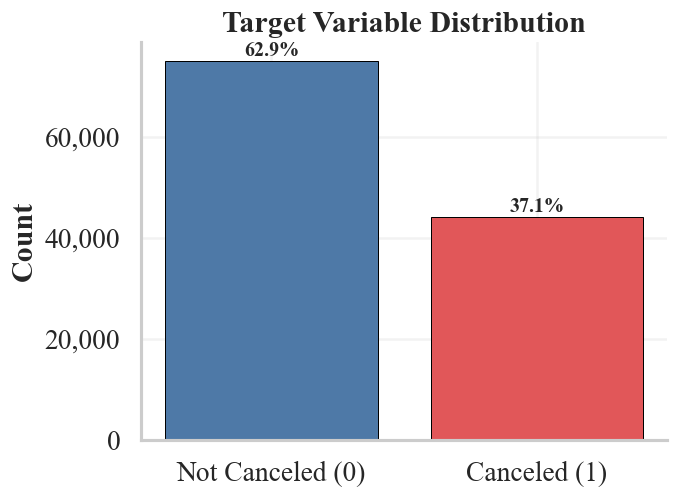

Cancellation rate: 37.1% (44,198 / 119,208)


In [7]:
target_counts = df[TARGET_COL].value_counts().sort_index()
target_pcts = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(
    ["Not Canceled (0)", "Canceled (1)"],
    target_counts.values,
    color=["#4e79a7", "#e15759"],
    edgecolor="black",
    linewidth=0.6,
)
for bar, pct in zip(bars, target_pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )
ax.set_ylabel("Count")
ax.set_title("Target Variable Distribution")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig.tight_layout()
plt.show()

print(f"Cancellation rate: {target_pcts.iloc[1]:.1f}% ({target_counts.iloc[1]:,} / {len(df):,})")

**What does 37% mean?** Roughly one in three bookings is eventually cancelled. This is a *moderate class imbalance* — not so extreme that we need complex oversampling techniques, but enough that accuracy alone is a misleading metric. A model that predicted "never cancel" would still be 63% accurate. That is why we use **PR-AUC** (Precision-Recall Area Under Curve) as our primary metric: it focuses specifically on how well we detect cancellations.

## 1.4 Temporal Patterns

Monthly cancellation rate with a 3-month rolling mean, booking volume overlay, and train/val/test split boundaries.
This uses the pre-built `plot_monthly_trend()` from `notebook_utils`.

D:\PythonProject1\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


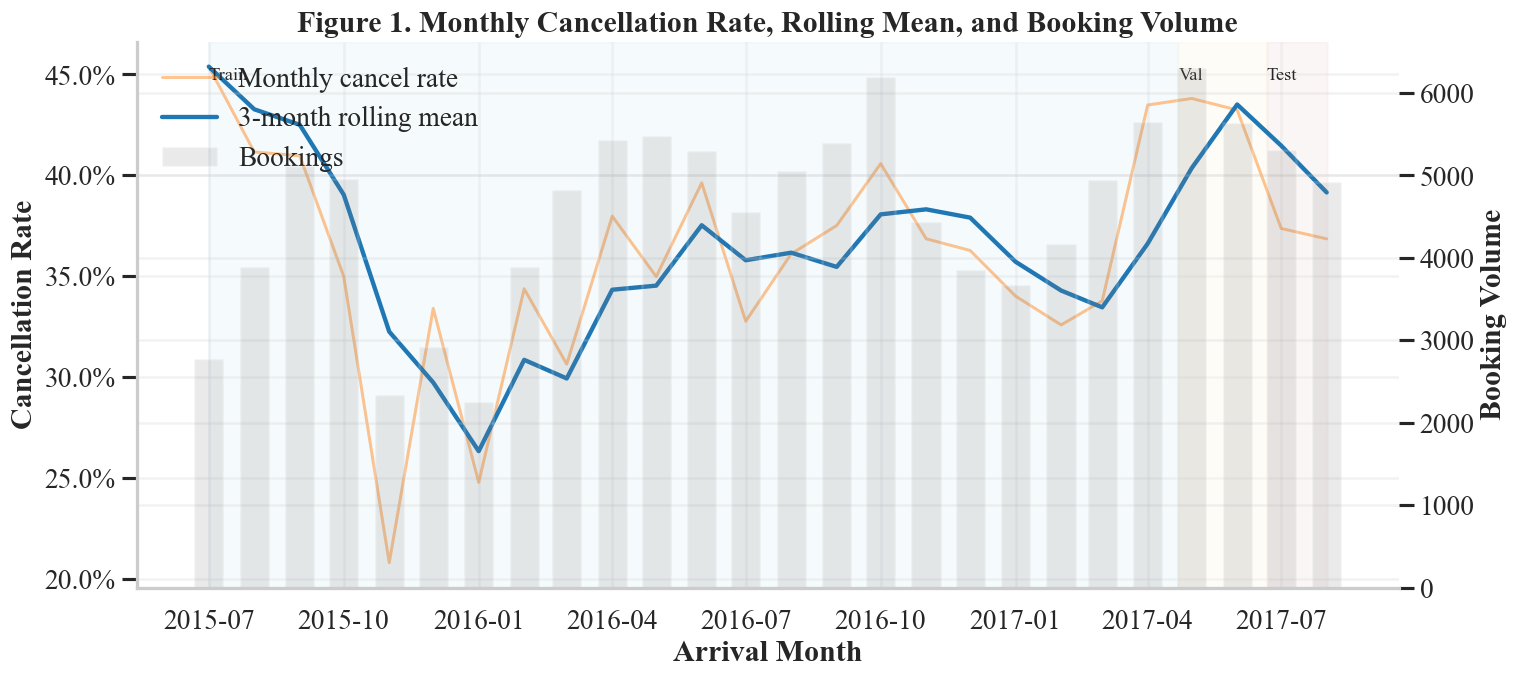

In [8]:
ctx = load_main_context()
plot_monthly_trend(ctx, FIG_DIR, fig_no=1)

The cancellation rate shows moderate seasonal variation with an upward trend in mid-2016 to early 2017.
The time-aware chronological split ensures the model is always evaluated on future data.

## 1.5 Numerical Feature Distributions

KDE distributions of key numerical features, split by cancellation status.

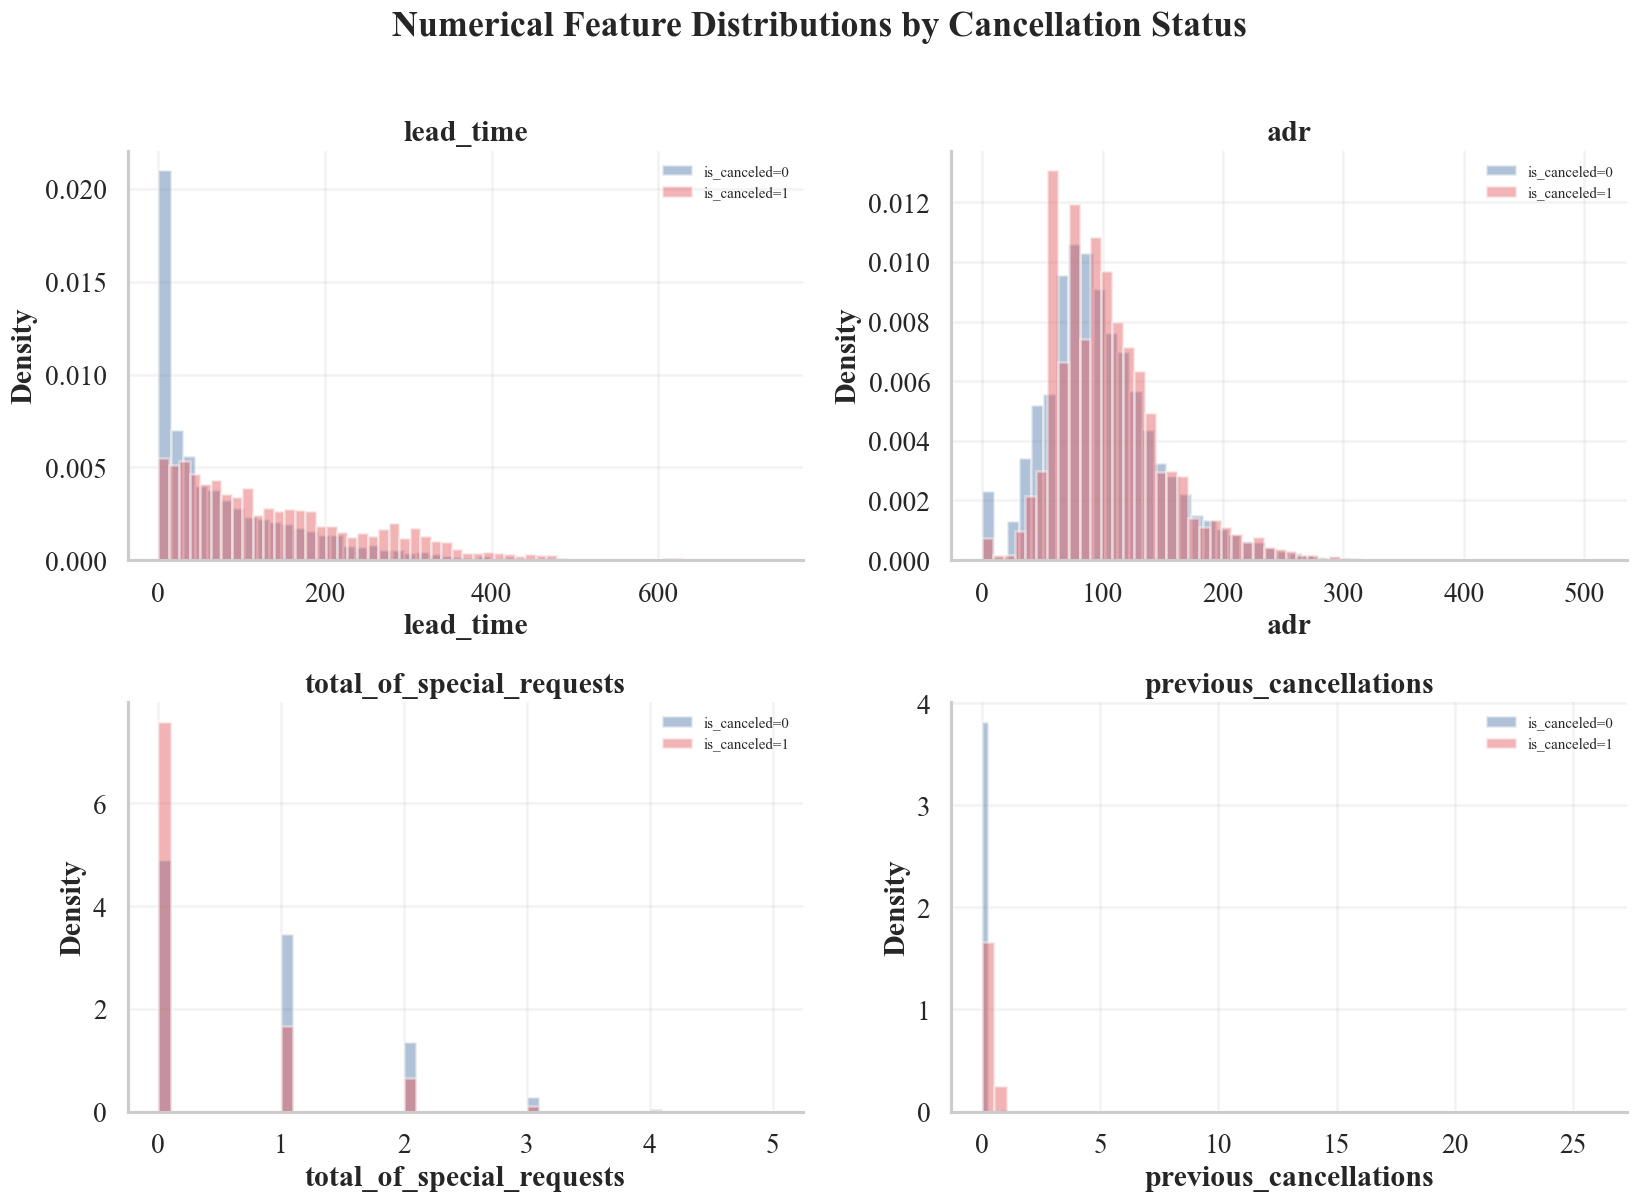

In [9]:
num_features = ["lead_time", "adr", "total_of_special_requests", "previous_cancellations"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), num_features):
    for label, color in [(0, "#4e79a7"), (1, "#e15759")]:
        subset = df.loc[df[TARGET_COL] == label, col].dropna()
        if subset.empty:
            continue
        ax.hist(
            subset,
            bins=50,
            density=True,
            alpha=0.45,
            color=color,
            label=f"{TARGET_COL}={label}",
        )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Numerical Feature Distributions by Cancellation Status", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

**Reading these histograms:** Each chart shows the distribution of one booking feature, split by whether the booking was cancelled (red) or not (blue). Key observations:
- **Lead time**: Cancelled bookings have a much longer lead time (median ~130 days) vs. kept bookings (~45 days). Guests who book far in advance are more likely to change plans.
- **ADR**: Cancelled bookings cluster at slightly higher ADR (room rate), suggesting price sensitivity plays a role.
- **Special requests**: Guests with zero special requests cancel more often — they are less emotionally invested in the specific stay.

These patterns directly inform which features matter most to the model.

**Key observations**:
- **Lead time**: Canceled bookings tend to have much longer lead times (right-skewed).
- **ADR**: Slight rightward shift for cancellations — higher-priced bookings cancel slightly more often.
- **Special requests**: Bookings with more special requests are less likely to cancel (signal of commitment).
- **Previous cancellations**: Repeat cancellers show a strong recurrence pattern.

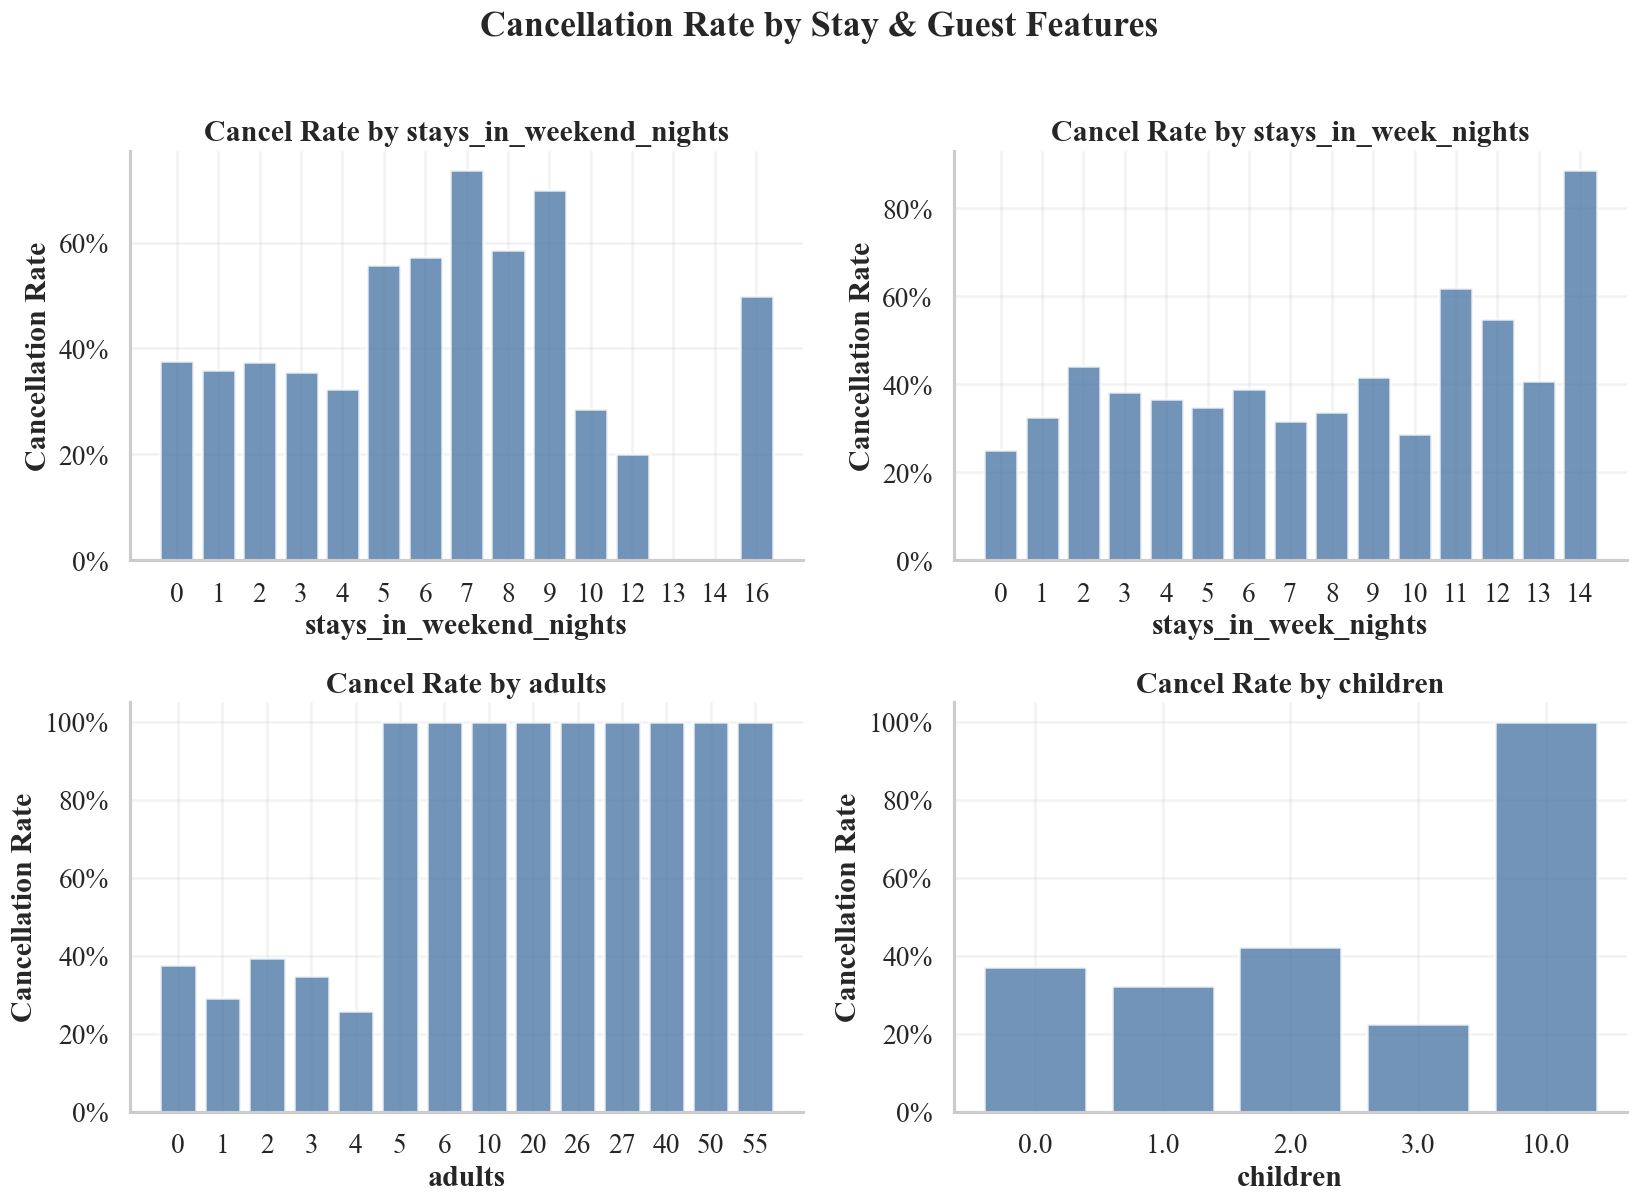

In [10]:
stay_features = ["stays_in_weekend_nights", "stays_in_week_nights", "adults", "children"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), stay_features):
    cancel_rate = df.groupby(col)[TARGET_COL].mean()
    counts = df[col].value_counts().sort_index()
    top_values = counts.head(15).index
    cancel_rate = cancel_rate.loc[cancel_rate.index.isin(top_values)]
    ax.bar(cancel_rate.index.astype(str), cancel_rate.values, color="#4e79a7", alpha=0.8)
    ax.set_title(f"Cancel Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Cancellation Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle("Cancellation Rate by Stay & Guest Features", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 1.6 Categorical Feature Analysis

Cancellation rates broken down by key categorical variables.

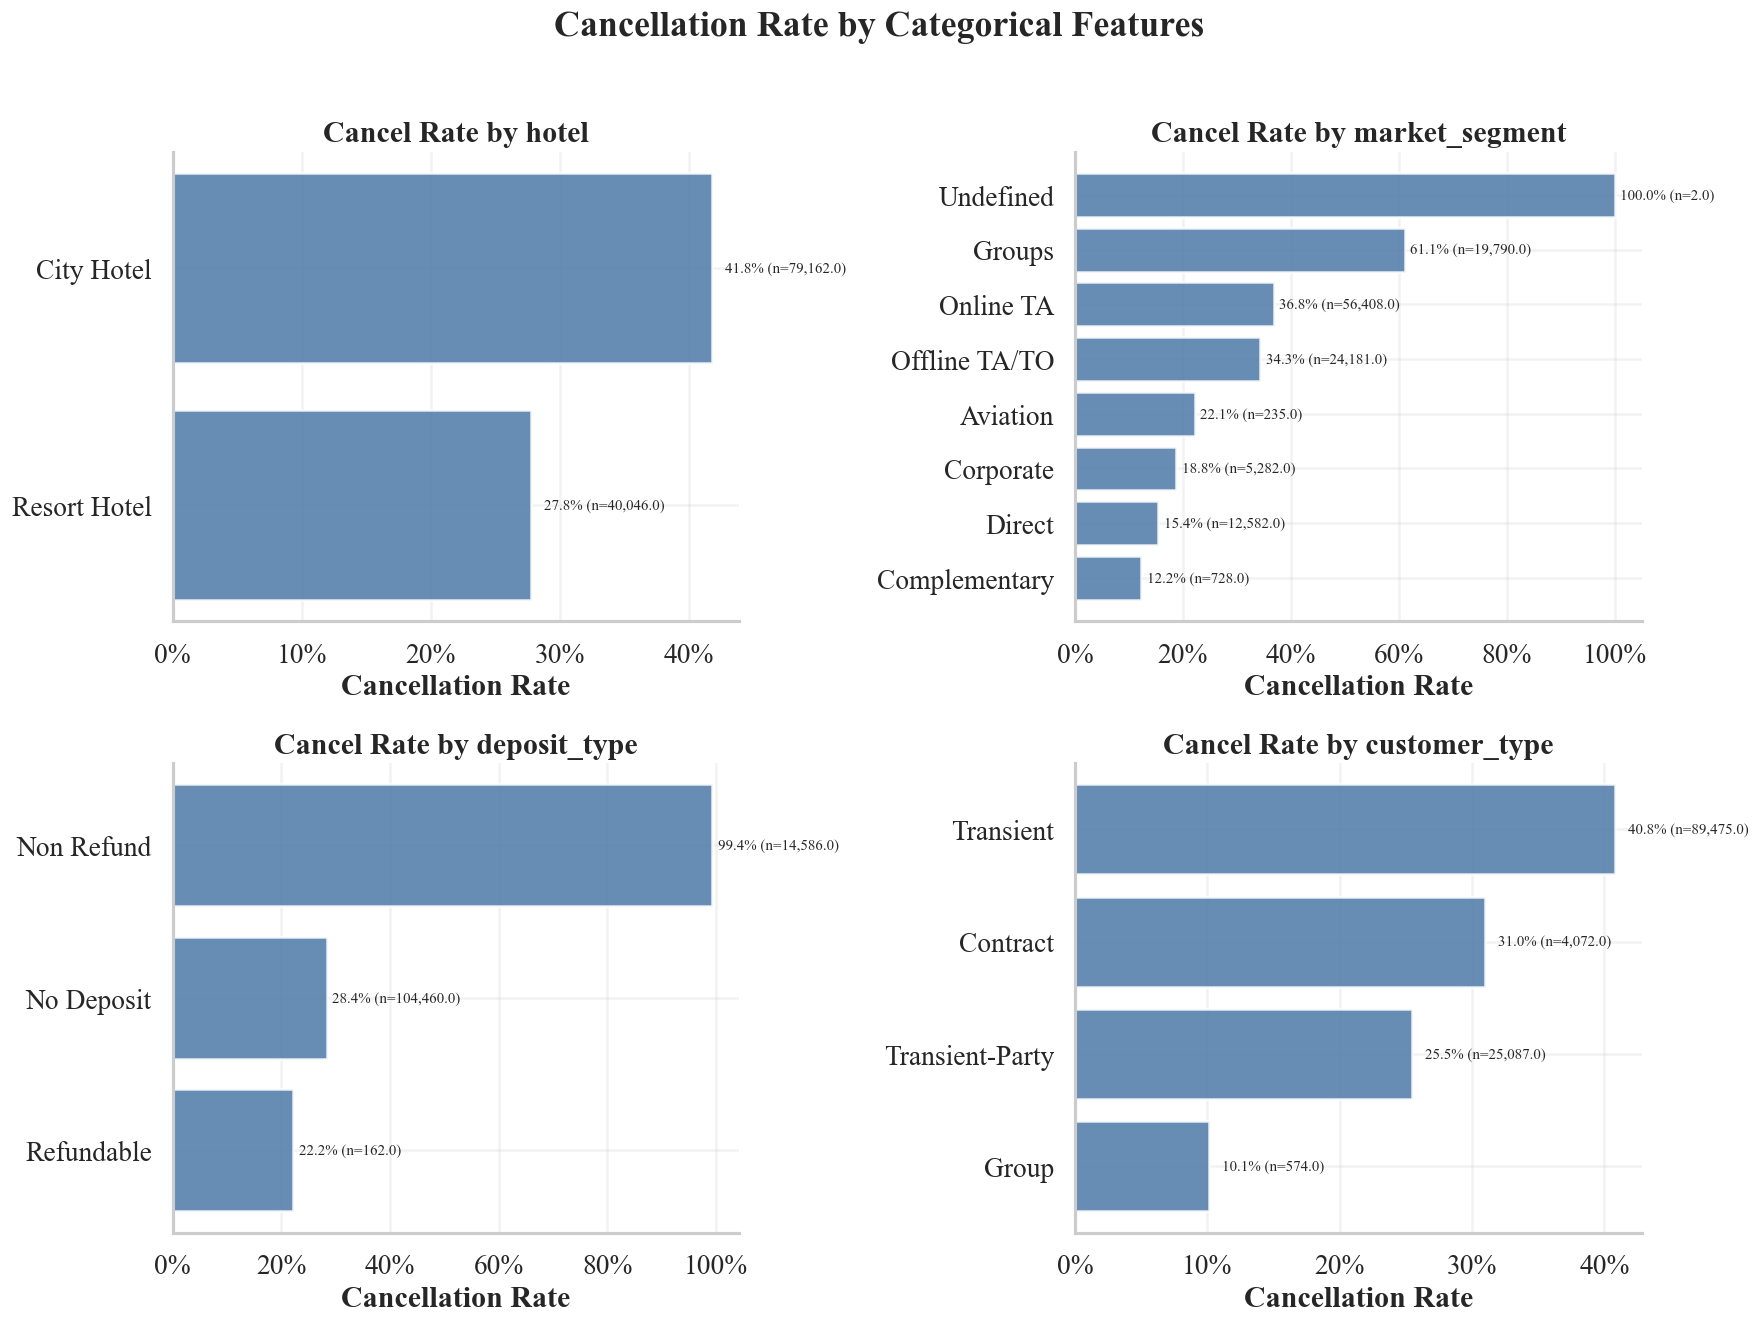

In [11]:
cat_features = ["hotel", "market_segment", "deposit_type", "customer_type"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, col in zip(axes.ravel(), cat_features):
    summary = (
        df.groupby(col)[TARGET_COL]
        .agg(["mean", "count"])
        .rename(columns={"mean": "cancel_rate", "count": "n"})
        .sort_values("cancel_rate", ascending=True)
    )
    bars = ax.barh(summary.index.astype(str), summary["cancel_rate"], color="#4e79a7", alpha=0.85)
    for bar, (_, row) in zip(bars, summary.iterrows()):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{row['cancel_rate']:.1%} (n={row['n']:,})",
            va="center",
            fontsize=9,
        )
    ax.set_title(f"Cancel Rate by {col}")
    ax.set_xlabel("Cancellation Rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle("Cancellation Rate by Categorical Features", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

**Important caveat — Non-Refundable deposits:** The near-100% cancellation rate for "Non Refund" deposit bookings looks alarming, but it reflects a *business accounting convention*: when a non-refundable booking is cancelled, the hotel still records it as a "cancellation" (the room is released) even though the revenue is retained. This is a data artefact, not a genuine prediction signal — and it is why we carefully exclude post-booking leakage columns from the model.

**Key observations**:
- **Hotel type**: City hotels have a notably higher cancellation rate than resort hotels.
- **Deposit type**: `Non Refund` deposits show near-100% cancellation — a strong signal but also a potential business rule rather than predictive feature.
- **Market segment**: Online TA and Groups have the highest cancellation rates.
- **Customer type**: Transient customers cancel most frequently.

## 1.7 Correlation Analysis & Leakage Columns

Correlation heatmap for numeric features. We also highlight the **leakage columns** that are excluded from modeling
because they contain post-booking information.

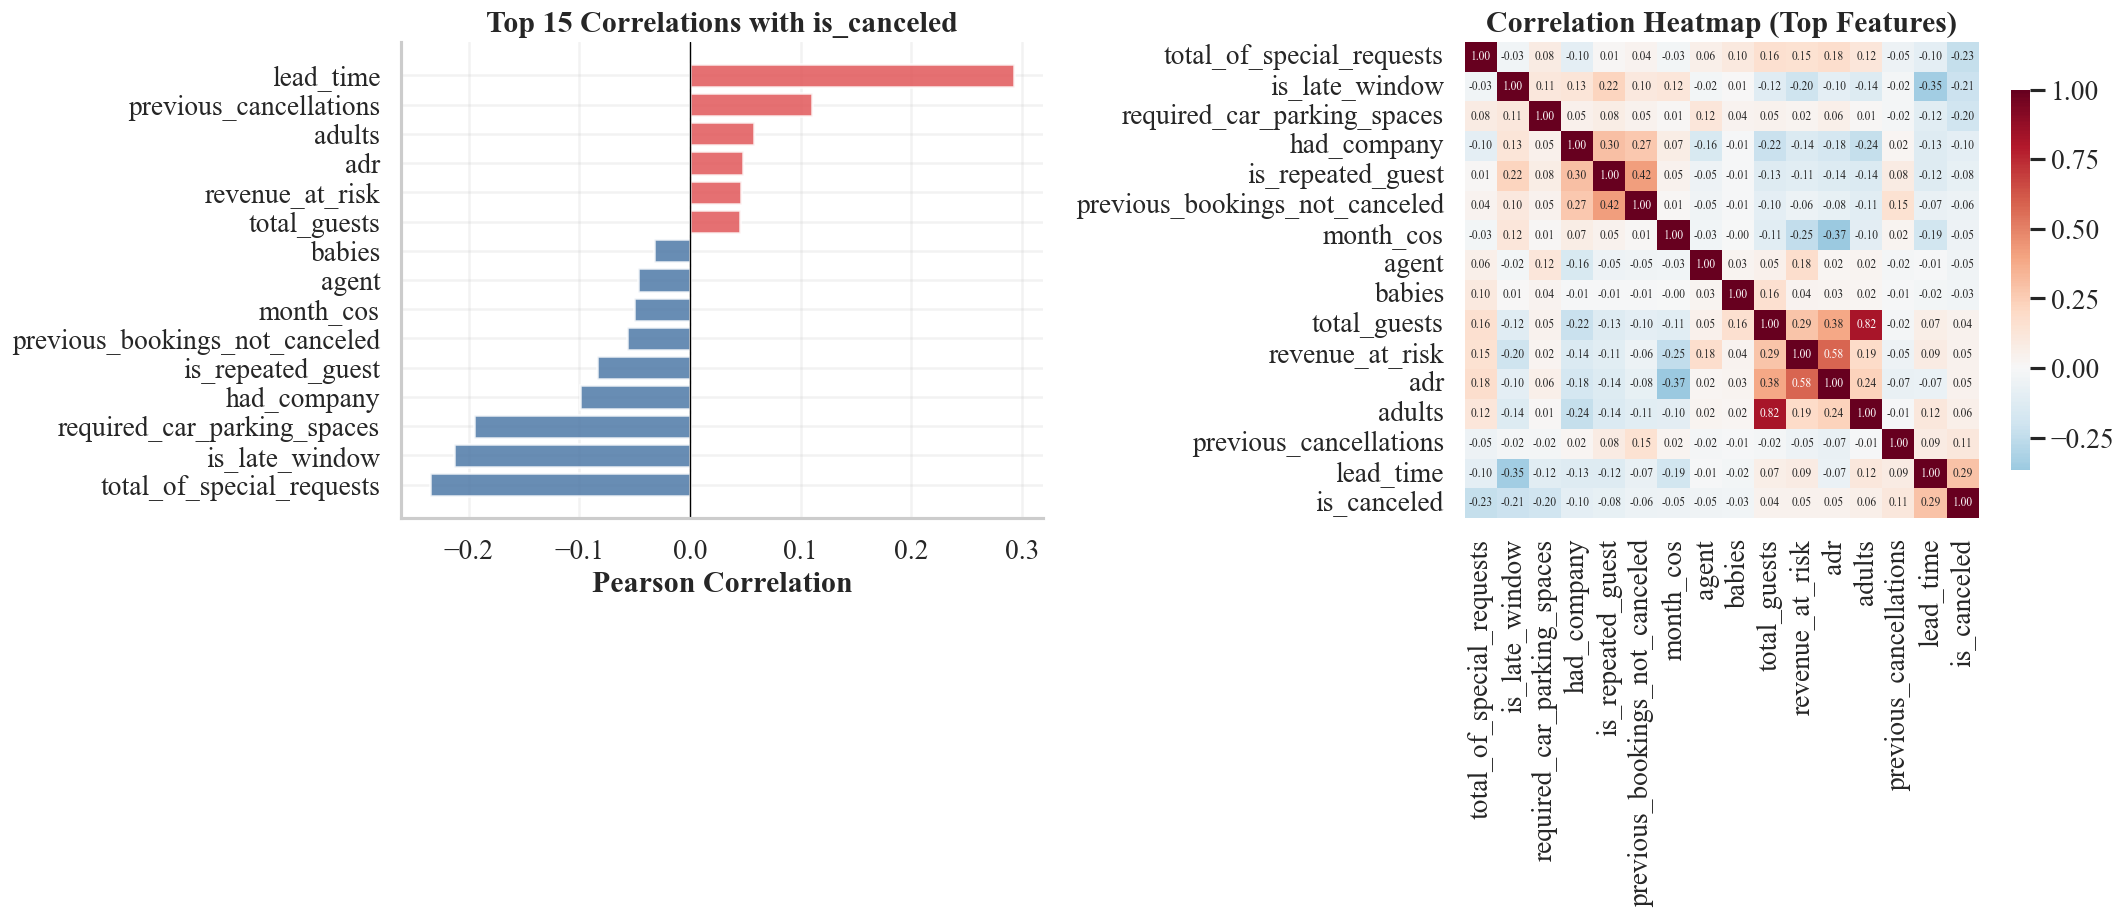

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Focus on the most relevant features (skip highly sparse ones)
corr_cols = [
    c for c in numeric_cols
    if c in BOOKING_TIME_FEATURES or c == TARGET_COL
]
corr_matrix = df[corr_cols].corr()

# Show correlations with target
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: top correlations with target
ax = axes[0]
top_n = 15
top_corr = target_corr.head(top_n).sort_values()
colors = ["#e15759" if v > 0 else "#4e79a7" for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, alpha=0.85)
ax.set_title(f"Top {top_n} Correlations with {TARGET_COL}")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.8)

# Right: full heatmap (top features only for readability)
ax = axes[1]
heatmap_cols = list(top_corr.index) + [TARGET_COL]
sns.heatmap(
    df[heatmap_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 7},
)
ax.set_title("Correlation Heatmap (Top Features)")

fig.tight_layout()
plt.show()

In [13]:
leakage_in_data = [c for c in LEAKAGE_COLS if c in df_raw.columns]
leakage_df = pd.DataFrame({
    "column": leakage_in_data,
    "reason": [
        "Directly derived from outcome" if c == "reservation_status" else
        "Known only after check-in/outcome" if c == "reservation_status_date" else
        "Assigned at check-in, not booking time" if c == "assigned_room_type" else
        "Accumulated post-booking" if c == "booking_changes" else
        "Post-booking operational metric"
        for c in leakage_in_data
    ],
})
display(
    leakage_df.style
    .set_caption("Leakage Columns Excluded from Modeling")
    .hide(axis="index")
)

column,reason
reservation_status,Directly derived from outcome
reservation_status_date,Known only after check-in/outcome
assigned_room_type,"Assigned at check-in, not booking time"
booking_changes,Accumulated post-booking
days_in_waiting_list,Post-booking operational metric


These columns are excluded because they contain information that would not be available at **booking time**
(the prediction point). Including them would leak future information and inflate model performance unrealistically.

## 1.8 Key Takeaways

1. **Class balance**: ~37% cancellation rate — moderate imbalance but not extreme. No need for aggressive oversampling.
2. **Lead time** is the single strongest predictor: longer lead times correlate strongly with cancellation.
3. **Deposit type** is a near-deterministic feature: `Non Refund` deposits cancel at ~99%. This is likely a business rule.
4. **Temporal drift**: The cancellation rate is not stationary — it trends upward in late 2016, making a chronological train/val/test split essential.
5. **Missing data**: `company` is 94% missing (imputed as absent); `agent` is 14% missing; both are handled during preprocessing.
6. **Leakage prevention**: 5 post-booking columns are explicitly excluded via `LEAKAGE_COLS` in config.

These findings motivate the feature engineering and modeling decisions in **Notebook 02**.